# 1. Install & Import

In [1]:
!pip install datasets

In [2]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 2. Loading Yelp Dataset

In [3]:
dataset = load_dataset("yelp_review_full")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

# 3. Convert to Pandas & Apply Your Labeling Rule

In [4]:
df_train = pd.DataFrame(dataset["train"])
df_test = pd.DataFrame(dataset["test"])

# 4. Map Labels to Stars → Then to Positive/Negative

In [5]:
df_train["stars"] = df_train["label"] + 1
df_test["stars"] = df_test["label"] + 1

df_train["sentiment"] = df_train["stars"].apply(lambda x: 1 if x >= 3 else 0)
df_test["sentiment"]  = df_test["stars"].apply(lambda x: 1 if x >= 3 else 0)

# 5. Text Cleaning Function

In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_train["clean"] = df_train["text"].apply(clean_text)
df_test["clean"] = df_test["text"].apply(clean_text)


# 6. TF-IDF Vectorization

In [7]:
tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1,2))

X_train = tfidf.fit_transform(df_train["clean"])
y_train = df_train["sentiment"]

X_test = tfidf.transform(df_test["clean"])
y_test = df_test["sentiment"]

# 7. Train the Logistic Regression Model

In [8]:
model = LogisticRegression(max_iter=300)
model.fit(X_train, y_train)

LogisticRegression(max_iter=300)

# 8. Evaluation

In [9]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.89192

Confusion Matrix:
[[17147  2853]
 [ 2551 27449]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.86     20000
           1       0.91      0.91      0.91     30000

    accuracy                           0.89     50000
   macro avg       0.89      0.89      0.89     50000
weighted avg       0.89      0.89      0.89     50000



# 9. Try a Custom Review

In [10]:
sample = ["The food was horrible and the service was even worse."]
sample_vec = tfidf.transform(sample)
print("Prediction (1=positive, 0=negative):", model.predict(sample_vec))

Prediction (1=positive, 0=negative): [0]


# Simple Sentiment Analysis

Sentiment Prediction Results
 1. This movie was absolutely amazing! Great stor... | True: Positive | Predicted: Positive ✓
 2. This was the worst product I’ve ever bought. ... | True: Negative | Predicted: Negative ✓
 3. Excellent service and very polite staff. A pl... | True: Positive | Predicted: Positive ✓
 4. Total waste of money. Not satisfied at all.... | True: Negative | Predicted: Negative ✓
 5. Outstanding build quality. Worth every dollar... | True: Positive | Predicted: Positive ✓
 6. Delivery was extremely late and the product w... | True: Negative | Predicted: Positive ✗
 7. Beautiful design and great performance. Highl... | True: Positive | Predicted: Positive ✓
 8. Not what the description promised. Very disap... | True: Negative | Predicted: Negative ✓
 9. Customer support was responsive and fixed my ... | True: Positive | Predicted: Negative ✗
10. Wonderful experience! I will definitely come ... | True: Positive | Predicted: Negative ✗

Confusion Matrix:


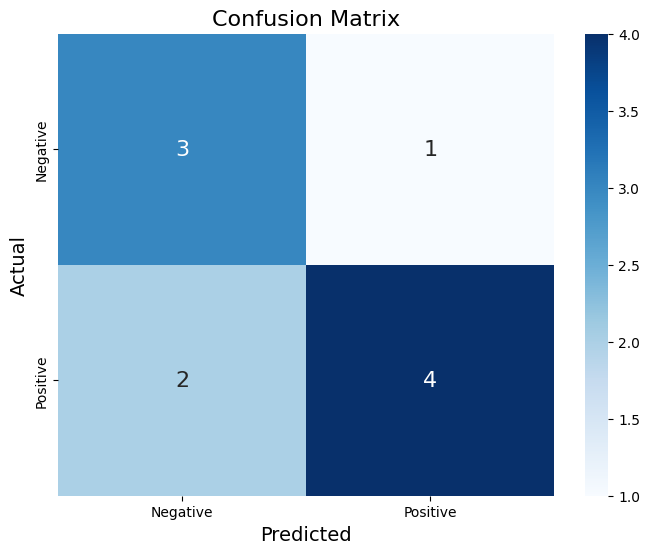


Confusion Matrix Details:
True Negative (TN):  3
False Positive (FP): 1
False Negative (FN): 2
True Positive (TP):  4

Evaluation Metrics
Accuracy:   0.7000 (70.0%)
Precision:  0.8000 (80.0%)
Recall:     0.6667 (66.7%)
F1-Score:   0.7273 (72.7%)

Manual Metric Verification
Manual Accuracy:   0.7000
Manual Precision:  0.8000
Manual Recall:     0.6667
Manual F1-Score:   0.7273

Full Classification Report
              precision    recall  f1-score   support

    Negative     0.6000    0.7500    0.6667         4
    Positive     0.8000    0.6667    0.7273         6

    accuracy                         0.7000        10
   macro avg     0.7000    0.7083    0.6970        10
weighted avg     0.7200    0.7000    0.7030        10



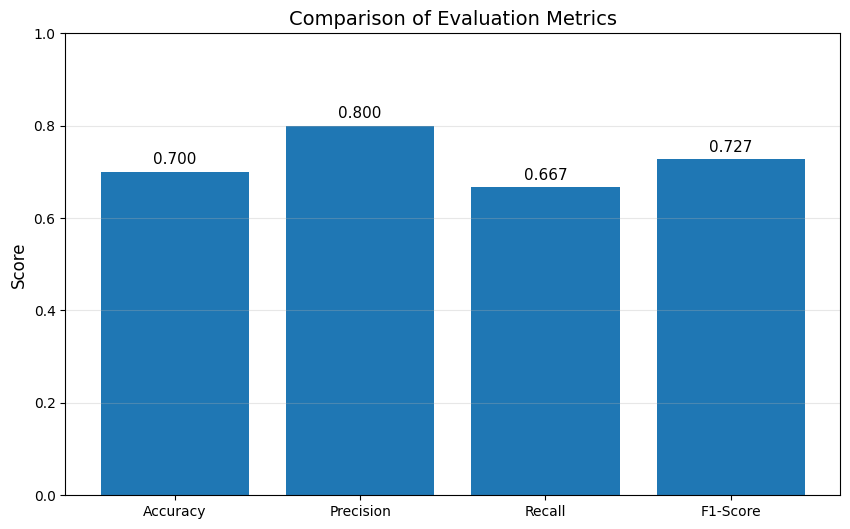


Summary
✔ Correct predictions:        7
✘ Incorrect predictions:      3
📊 Overall Accuracy:          70.0%
🎯 Positive-Class Precision:  80.0%
🔍 Positive-Class Recall:     66.7%


In [11]:
# -*- coding: utf-8 -*-
"""
Simple Sentiment Analysis (English Version)

This section demonstrates a basic rule-based sentiment classifier,
similar to the original Persian example, but rewritten and structured
professionally in English.

This mock example provides the foundation before we move on to the
full Yelp dataset sentiment analysis.
"""

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)
import random
import warnings
warnings.filterwarnings("ignore")

# Configure plot font
plt.rcParams['font.family'] = 'DejaVu Sans'

# --------------------------------------------------------------
# Sample Dataset
# --------------------------------------------------------------
texts = [
    "This movie was absolutely amazing! Great story and fantastic actors.",
    "This was the worst product I’ve ever bought. Completely useless.",
    "Excellent service and very polite staff. A pleasant experience.",
    "Total waste of money. Not satisfied at all.",
    "Outstanding build quality. Worth every dollar.",
    "Delivery was extremely late and the product was damaged.",
    "Beautiful design and great performance. Highly recommended.",
    "Not what the description promised. Very disappointed.",
    "Customer support was responsive and fixed my issue quickly.",
    "Wonderful experience! I will definitely come back."
]

# True labels (1 = positive, 0 = negative)
true_labels = [1, 0, 1, 0, 1, 0, 1, 0, 1, 1]

# --------------------------------------------------------------
# Simple Rule-Based Sentiment Predictor
# --------------------------------------------------------------

def predict_sentiment(text):
    """
    Simple heuristic:
      - If text contains 'great' or 'excellent' → positive
      - If text contains 'worst' or 'not' → negative
      - Otherwise → random guess

    This is intentionally simple just for demonstration.
    """
    t = text.lower()
    if 'great' in t or 'excellent' in t:
        return 1
    elif 'worst' in t or 'not' in t:
        return 0
    else:
        return random.choice([0, 1])

predicted_labels = [predict_sentiment(t) for t in texts]

# --------------------------------------------------------------
# Print Prediction Results
# --------------------------------------------------------------

print("=" * 70)
print("Sentiment Prediction Results")
print("=" * 70)

for i, (text, true, pred) in enumerate(zip(texts, true_labels, predicted_labels)):
    true_str = "Positive" if true == 1 else "Negative"
    pred_str = "Positive" if pred == 1 else "Negative"
    status   = "✓" if true == pred else "✗"
    print(f"{i+1:2d}. {text[:45]}... | True: {true_str:8s} | Predicted: {pred_str:8s} {status}")

print("\n" + "=" * 70)

# --------------------------------------------------------------
# Confusion Matrix
# --------------------------------------------------------------

cm = confusion_matrix(true_labels, predicted_labels)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print("=" * 50)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    annot_kws={"size": 16}
)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)
plt.show()

print("\nConfusion Matrix Details:")
print(f"True Negative (TN):  {tn}")
print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")
print(f"True Positive (TP):  {tp}")

# --------------------------------------------------------------
# Evaluation Metrics
# --------------------------------------------------------------

accuracy  = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels)
recall    = recall_score(true_labels, predicted_labels)
f1        = f1_score(true_labels, predicted_labels)

print("\n" + "=" * 70)
print("Evaluation Metrics")
print("=" * 70)
print(f"Accuracy:   {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"Precision:  {precision:.4f} ({precision*100:.1f}%)")
print(f"Recall:     {recall:.4f} ({recall*100:.1f}%)")
print(f"F1-Score:   {f1:.4f} ({f1*100:.1f}%)")

# Manual verification
manual_accuracy  = (tp + tn) / (tp + tn + fp + fn)
manual_precision = tp / (tp + fp) if (tp + fp) else 0
manual_recall    = tp / (tp + fn) if (tp + fn) else 0
manual_f1        = 2 * (manual_precision * manual_recall) / (manual_precision + manual_recall) if (manual_precision + manual_recall) else 0

print("\n" + "=" * 70)
print("Manual Metric Verification")
print("=" * 70)
print(f"Manual Accuracy:   {manual_accuracy:.4f}")
print(f"Manual Precision:  {manual_precision:.4f}")
print(f"Manual Recall:     {manual_recall:.4f}")
print(f"Manual F1-Score:   {manual_f1:.4f}")

# --------------------------------------------------------------
# Classification Report
# --------------------------------------------------------------

print("\n" + "=" * 70)
print("Full Classification Report")
print("=" * 70)
print(classification_report(
    true_labels, predicted_labels,
    target_names=['Negative', 'Positive'], digits=4
))

# --------------------------------------------------------------
# Metrics Comparison Chart
# --------------------------------------------------------------

metrics_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [accuracy, precision, recall, f1]

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics_names, metrics_values)

plt.ylim(0, 1)
plt.ylabel('Score', fontsize=12)
plt.title('Comparison of Evaluation Metrics', fontsize=14)

# Add labels on bars
for bar, value in zip(bars, metrics_values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{value:.3f}',
        ha='center', va='bottom', fontsize=11
    )

plt.grid(axis='y', alpha=0.3)
plt.show()

# --------------------------------------------------------------
# Summary
# --------------------------------------------------------------

print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print(f"✔ Correct predictions:        {tp + tn}")
print(f"✘ Incorrect predictions:      {fp + fn}")
print(f"📊 Overall Accuracy:          {accuracy*100:.1f}%")
print(f"🎯 Positive-Class Precision:  {precision*100:.1f}%")
print(f"🔍 Positive-Class Recall:     {recall*100:.1f}%")


# Confusion Matrix

                     Confusion Matrix

Confusion Matrix (Textual Representation):
                    Predicted
                Positive      Negative
Actual Positive     4            2
Actual Negative     1            3


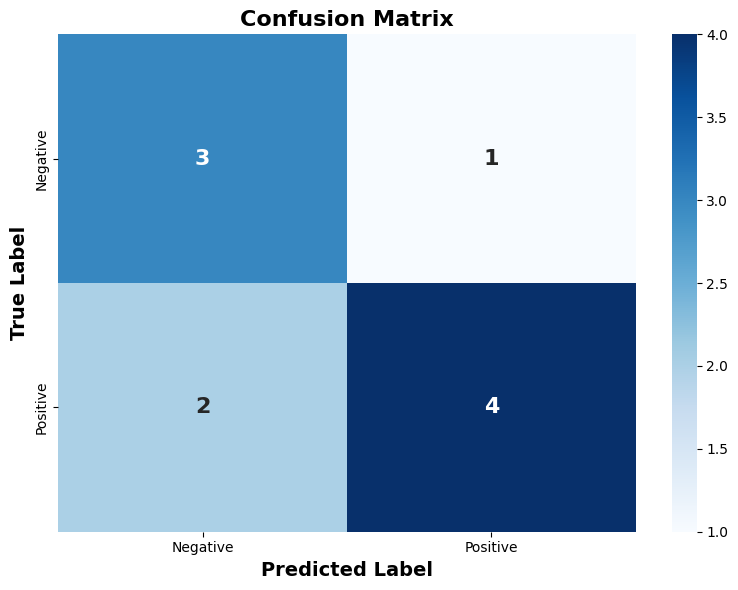


Detailed Breakdown:
True Positive (TP):  4  - Correctly predicted positive
True Negative (TN):  3  - Correctly predicted negative
False Positive (FP): 1  - Incorrectly predicted positive
False Negative (FN): 2  - Incorrectly predicted negative

Overall Statistics:
Total Samples:       10
Correct Predictions: 7
Wrong Predictions:   3
Error Rate:          0.300

Metrics for Positive Class:
Sensitivity (Recall): 0.667
Precision:            0.800

Metrics for Negative Class:
Specificity:          0.750
Negative Precision:   0.600


In [12]:
# ================================================================
#                   Confusion Matrix Visualization
# ================================================================

print("=" * 60)
print("                     Confusion Matrix")
print("=" * 60)

# Compute confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)
tn, fp, fn, tp = cm.ravel()

# Display confusion matrix in text format
print("\nConfusion Matrix (Textual Representation):")
print(f"                    Predicted")
print(f"                Positive      Negative")
print(f"Actual Positive     {tp}            {fn}")
print(f"Actual Negative     {fp}            {tn}")

# Graphical visualization
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    annot_kws={"size": 16, "weight": "bold"}
)

plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Detailed breakdown of confusion matrix components
print("\nDetailed Breakdown:")
print(f"True Positive (TP):  {tp}  - Correctly predicted positive")
print(f"True Negative (TN):  {tn}  - Correctly predicted negative")
print(f"False Positive (FP): {fp}  - Incorrectly predicted positive")
print(f"False Negative (FN): {fn}  - Incorrectly predicted negative")

# Overall statistics
total = tp + tn + fp + fn
correct_predictions = tp + tn
wrong_predictions = fp + fn

print("\nOverall Statistics:")
print(f"Total Samples:       {total}")
print(f"Correct Predictions: {correct_predictions}")
print(f"Wrong Predictions:   {wrong_predictions}")
print(f"Error Rate:          {wrong_predictions / total:.3f}")

# Class-wise metrics
print("\nMetrics for Positive Class:")
print(f"Sensitivity (Recall): {tp / (tp + fn):.3f}" if (tp + fn) > 0 else "Undefined")
print(f"Precision:            {tp / (tp + fp):.3f}" if (tp + fp) > 0 else "Undefined")

print("\nMetrics for Negative Class:")
print(f"Specificity:          {tn / (tn + fp):.3f}" if (tn + fp) > 0 else "Undefined")
print(f"Negative Precision:   {tn / (tn + fn):.3f}" if (tn + fn) > 0 else "Undefined")


# Class Distribution + Word Clouds

In [14]:
from sklearn.model_selection import train_test_split

# First split: train + temp
df_train, df_temp = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])

# Second split: validate + test
df_validation, df_test = train_test_split(df_temp, test_size=0.5, random_state=42, stratify=df_temp['label'])

NameError: name 'df' is not defined

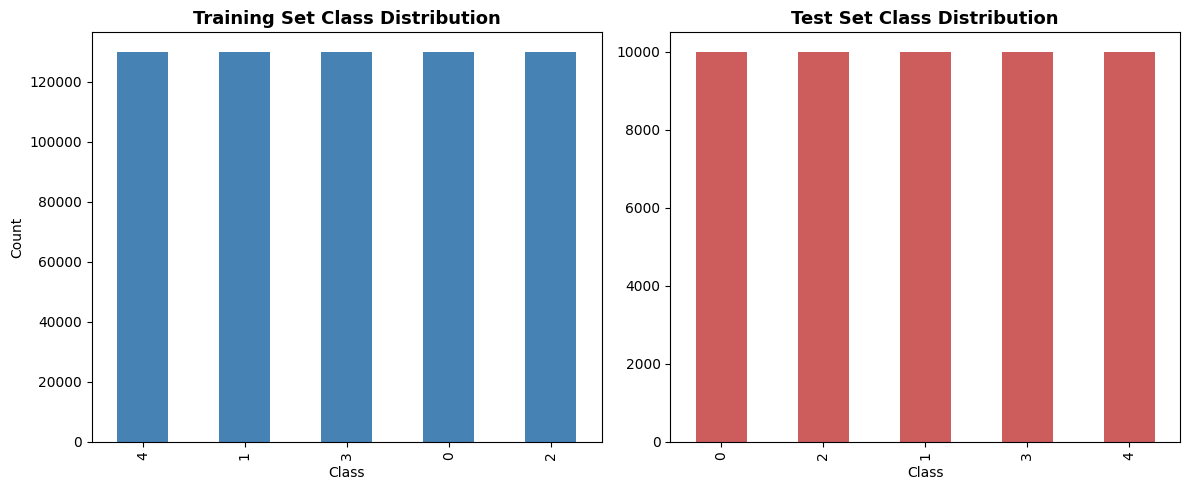

Training Set Class Distribution:
label
4    130000
1    130000
3    130000
0    130000
2    130000
Name: count, dtype: int64

Test Set Class Distribution:
label
0    10000
2    10000
1    10000
3    10000
4    10000
Name: count, dtype: int64


In [15]:
# ================================================================
#                 Class Distribution Visualization
# ================================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- Training Set ----
df_train['label'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color='steelblue'
)
axes[0].set_title("Training Set Class Distribution", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

# ---- Test Set ----
df_test['label'].value_counts().plot(
    kind='bar',
    ax=axes[1],
    color='indianred'
)
axes[1].set_title("Test Set Class Distribution", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Class")

plt.tight_layout()
plt.show()

# ---- Print Class Counts ----
print("Training Set Class Distribution:")
print(df_train['label'].value_counts())

print("\nTest Set Class Distribution:")
print(df_test['label'].value_counts())


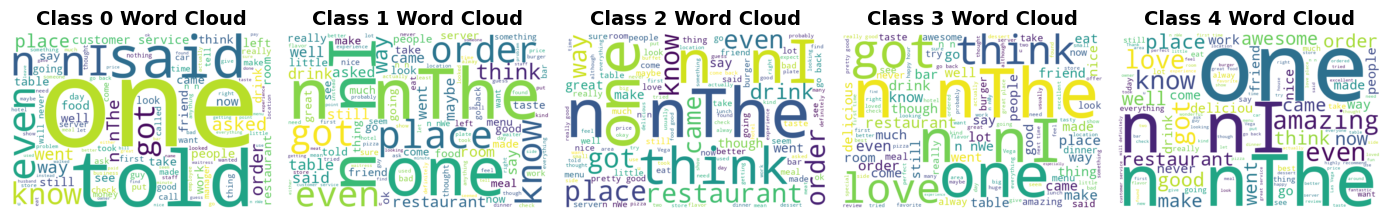

In [17]:
# ================================================================
#                       Word Cloud Generation
# ================================================================

from wordcloud import WordCloud
from collections import Counter
import matplotlib.pyplot as plt

# Basic stopwords for English dataset
stop_words = {
    'and', 'the', 'is', 'be', 'was', 'were', 'are', 'to', 'in', 'it',
    'for', 'of', 'that', 'this', 'a', 'an', 'on', 'with', 'as', 'at',
    'but', 'we', 'they', 'you', 'i', 'not', 'so', 'if'
}

def preprocess_text(text):
    """Remove stopwords and keep informative tokens."""
    words = text.split()
    filtered = [w for w in words if w.lower() not in stop_words]
    return ' '.join(filtered)

classes = df_train['label'].unique()
classes.sort()

fig, axes = plt.subplots(1, len(classes), figsize=(14, 5))

for i, class_label in enumerate(classes):
    # Concatenate all comments for that class
    text_data = ' '.join(df_train[df_train['label'] == class_label]['text']) # Changed 'review' to 'text'
    processed = preprocess_text(text_data)

    # Generate word cloud
    try:
        wc = WordCloud(
            background_color='white',
            width=600,
            height=400,
            max_words=120
        ).generate(processed)
    except Exception as e:
        print(f"Error generating word cloud for class {class_label}: {e}")
        continue

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f"Class {class_label} Word Cloud", fontsize=14, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [19]:
# ================================================================
#                  Most Frequent Words Per Class
# ================================================================

print("Most Frequent Words Per Class (After Preprocessing):")

for class_label in classes:
    text_data = ' '.join(df_train[df_train['label'] == class_label]['text'])
    processed = preprocess_text(text_data)

    words = processed.split()
    common_words = Counter(words).most_common(12)

    print(f"\nClass {class_label}:")
    for w, count in common_words:
        print(f"  {w:<15} {count}")

Most Frequent Words Per Class (After Preprocessing):

Class 0:
  my              178801
  have            121389
  had             114238
  me              91323
  our             71736
  would           66158
  get             65340
  out             63831
  just            62941
  there           60555
  like            59837
  place           55645

Class 1:
  my              136230
  have            114397
  had             112567
  just            75336
  like            73368
  food            69529
  our             66170
  place           61859
  get             60459
  out             58033
  there           57465
  would           56729

Class 2:
  my              108290
  have            105207
  had             94538
  like            67774
  just            64177
  good            63413
  place           63023
  food            59564
  get             52889
  or              52697
  very            52211
  out             49914

Class 3:
  have            97307
  my       